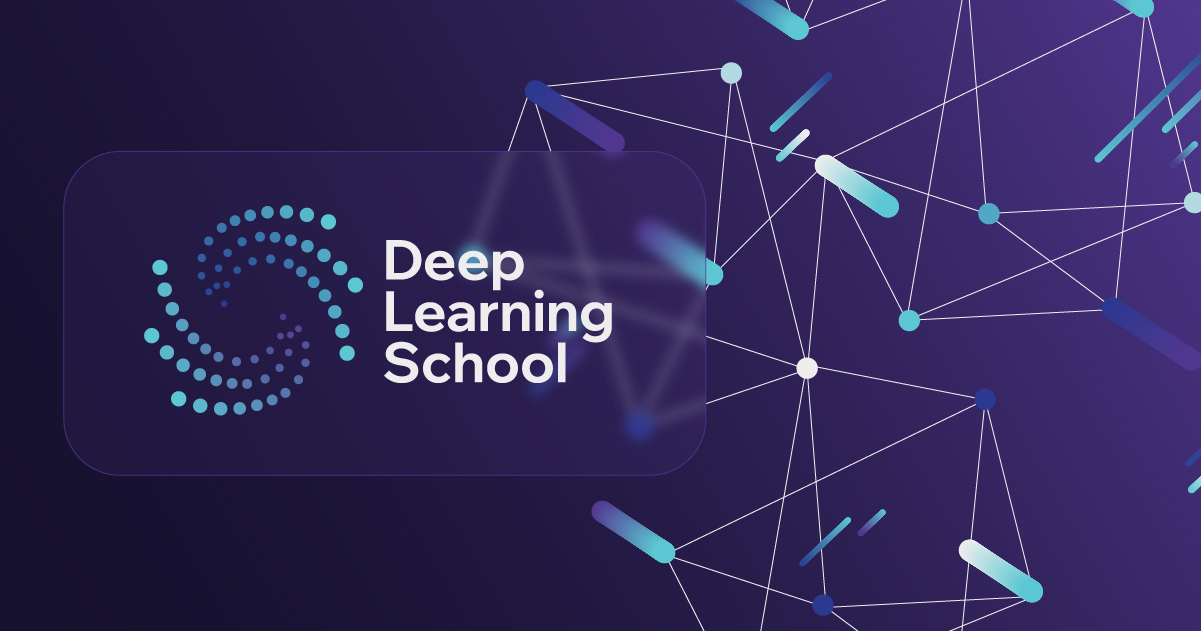

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание по теме "Механизм внимания.</b></h1>


Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Импорт библиотек

In [63]:
import torch
from transformers import AutoModel, AutoConfig
from transformers import get_linear_schedule_with_warmup
import torch.nn as nn

In [64]:
import copy
from typing import Union, Dict
from typing import Optional, List
from tqdm import tqdm

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [65]:
class TransformerClassificationModel(nn.Module):
    def __init__(self, base_transformer_model: Union[str, nn.Module],
                 num_labels: int = 2, dropout: float = 0.1):
        super().__init__()

        # Загрузка backbone модели
        if isinstance(base_transformer_model, str):
            self.backbone = AutoModel.from_pretrained(base_transformer_model)
            self.config = AutoConfig.from_pretrained(base_transformer_model)
        else:
            self.backbone = base_transformer_model
            self.config = base_transformer_model.config

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.config.hidden_size, num_labels)

    def forward(self, inputs: Dict[str, torch.Tensor]) -> Dict[
        str, torch.Tensor]:
        # Пропускаем через backbone
        outputs = self.backbone(**inputs)

        # Берем [CLS] token для классификации
        pooled_output = outputs.last_hidden_state[:, 0, :]

        # Пропускаем через classification head
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        outputs = {'logits': logits, 'hidden_states': outputs.hidden_states,
                   'attentions': outputs.attentions}
        return outputs

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

> сделал со многими параметрами для эеспериментов

In [66]:
def freeze_backbone_function(model: TransformerClassificationModel,
                             freeze_layers: Optional[List[int]] = None,
                             unfreeze_classifier: bool = True) -> TransformerClassificationModel:
    """
    Расширенная функция заморозки backbone с дополнительными опциями.

    Args:
        model: Экземпляр TransformerClassificationModel
        freeze_layers: Список номеров слоев для заморозки (если None - все слои)
        unfreeze_classifier: Размораживать ли classification head

    Returns:
        TransformerClassificationModel: Модель с замороженными слоями
    """

    if freeze_layers is None:
        # Замораживаем весь backbone
        for param in model.backbone.parameters():
            param.requires_grad = False
    else:
        # Выборочная заморозка определенных слоев
        for layer_idx, layer in enumerate(model.backbone.encoder.layer):
            if layer_idx in freeze_layers:
                for param in layer.parameters():
                    param.requires_grad = False

    # Управление заморозкой classification head
    if unfreeze_classifier:
        for param in model.classifier.parameters():
            param.requires_grad = True

        # Размораживаем другие дополнительные слои
        if hasattr(model, 'dropout'):
            for param in model.dropout.parameters():
                param.requires_grad = True

    return model

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

> обучение реализовал с простейшим линейным чедулером с начальным прогревом

In [67]:
def train_transformer(transformer_model, freeze_backbone=True,
                      train_loader=None, val_loader=None, num_epochs=3,
                      learning_rate=2e-5, warmup_steps=0):
    """
    Функция для дообучения TransformerClassificationModel

    Args:
        transformer_model: Исходная модель для дообучения
        freeze_backbone: Замораживать ли backbone
        warmup_steps: Количество шагов для warmup

    Returns:
        TransformerClassificationModel: Дообученная модель
    """

    # Создаем глубокую копию модели для безопасного изменения
    model = copy.deepcopy(transformer_model)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    # Замораживаем backbone если необходимо
    if freeze_backbone:
        for param in model.backbone.parameters():
            param.requires_grad = False
        print("Backbone заморожен. Обучается только classification head.")
    else:
        print("Backbone разморожен. Обучается вся модель.")

    # Настраиваем оптимизатор - только для параметров, которые требуют градиентов
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=learning_rate)

    # Функция потерь
    criterion = nn.CrossEntropyLoss()

    # Настраиваем планировщик обучения
    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(optimizer,
                                                num_warmup_steps=warmup_steps,
                                                num_training_steps=total_steps)

    # Цикл обучения
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        progress_bar = tqdm(train_loader,
                            desc=f'Epoch {epoch + 1}/{num_epochs}')

        for batch in progress_bar:
            # Переносим данные на устройство
            inputs = {k: v.to(device) for k, v in batch.items() if
                      k != 'labels'}
            labels = batch['labels'].to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(inputs)
            logits = outputs['logits']

            # Вычисление потерь
            loss = criterion(logits, labels)

            # Backward pass
            loss.backward()
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Валидация после каждой эпохи
        if val_loader is not None:
            val_loss, val_accuracy = evaluate_model(model, val_loader,
                                                    criterion, device)
            print(
                f'Epoch {epoch + 1}: Train Loss: {total_loss / len(train_loader):.4f}, '
                f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}')
        else:
            print(
                f'Epoch {epoch + 1}: Train Loss: {total_loss / len(train_loader):.4f}')

    print("Дообучение завершено!")
    return model


def evaluate_model(model, val_loader, criterion, device):
    """Функция для оценки модели на валидационных данных"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in val_loader:
            inputs = {k: v.to(device) for k, v in batch.items() if
                      k != 'labels'}
            labels = batch['labels'].to(device)

            outputs = model(inputs)
            logits = outputs['logits']

            loss = criterion(logits, labels)
            total_loss += loss.item()

            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    model.train()
    return total_loss / len(val_loader), correct / total

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

>> Про rubert-tiny2
Про rubert-tiny2 я расскажу подробнее, потому что эту модель я ранее нигде не описывал. Это доработанная версия rubert-tiny: я расширил словарь модели c 30К до 80К токенов, увеличил максимальную длину текста с 512 до 2048 токенов, и дообучил модель на комбинации задач masked language modelling, natural language inference, и аппроксимации эмбеддингов LaBSE. Код дообучения есть в блокноте.

[Рейтинг русскоязычных энкодеров предложений](https://habr.com/ru/articles/669674/)

> *cointegrated/rubert-tiny2* из huggingface это модель обученная на русских текстах, значит будем использовать русский датасет

In [68]:
#!pip install hf_xet

In [69]:
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
import torch

#### Датасет и подготовка данных

In [70]:
#!pip install openpyxl

In [71]:
df = pd.read_excel('data_problems.xlsx')

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5273 entries, 0 to 5272
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5273 non-null   int64 
 1   Задача      5273 non-null   object
 2   Тема        5273 non-null   object
dtypes: int64(1), object(2)
memory usage: 123.7+ KB


In [73]:
df.head()

,Unnamed: 0,Задача,Тема
0,0,Между девятью планетами Солнечной системы введ...,Графы
1,1,"В стране Цифра есть 9 городов с названиями 1, ...",Графы
2,2,"В государстве 100 городов, и из каждого из них...",Графы
3,3,"В классе 30 человек. Может ли быть так, что 9 ...",Графы
4,4,В городе Маленьком 15 телефонов. Можно ли их с...,Графы


In [74]:
# Кастомный датасет для наших данных
class ProblemsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Токенизация текста
        encoding = self.tokenizer(text, truncation=True, padding='max_length',
                                  max_length=self.max_length,
                                  return_tensors='pt')

        return {'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'labels': torch.tensor(label, dtype=torch.long)}

In [75]:
# Загрузка и подготовка данных
def prepare_data(file_path="data_problems.xlsx"):
    # Загружаем данные
    # df = pd.read_csv(file_path, sep=';')
    df = pd.read_excel(file_path)

    # Преобразуем topics в числовые метки
    topics = df['Тема'].unique()
    topic_to_id = {topic: i for i, topic in enumerate(topics)}
    id_to_topic = {i: topic for topic, i in topic_to_id.items()}

    print("Темы в датасете:")
    for topic, topic_id in topic_to_id.items():
        print(f"  {topic}: {topic_id}")

    # Создаем тексты и метки
    texts = df['Задача'].tolist()
    labels = [topic_to_id[topic] for topic in df['Тема']]

    # Статистика
    print(f"\nСтатистика датасета:")
    print(f"Всего примеров: {len(df)}")
    print(f"Распределение по темам:")
    for topic, topic_id in topic_to_id.items():
        count = sum(1 for label in labels if label == topic_id)
        print(f"  {topic}: {count} примеров")

    return texts, labels, topic_to_id, id_to_topic

#### Загрузка данных

> Данные разделил 80/20

In [76]:
print("Загружаем и подготавливаем данные...")
texts, labels, topic_to_id, id_to_topic = prepare_data("data_problems.xlsx")

# Инициализируем токенизатор для rubert-tiny2
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

# Создаем датасет и разделяем на train/val
dataset = ProblemsDataset(texts, labels, tokenizer)

# Разделяем данные на тренировочные и валидационные (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size,
                                                                     val_size],
                                                           generator=torch.Generator().manual_seed(
                                                               42))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"\nРазмеры датасетов:")
print(f"Тренировочный: {len(train_dataset)} примеров")
print(f"Валидационный: {len(val_dataset)} примеров")

Загружаем и подготавливаем данные...
Темы в датасете:
  Графы: 0
  Геометрия: 1
  Многочлен: 2
  Комбинаторика: 3
  Теория чисел: 4
  Инвариант: 5
  Дирихле: 6

Статистика датасета:
Всего примеров: 5273
Распределение по темам:
  Графы: 384 примеров
  Геометрия: 371 примеров
  Многочлен: 426 примеров
  Комбинаторика: 1020 примеров
  Теория чисел: 2396 примеров
  Инвариант: 235 примеров
  Дирихле: 441 примеров

Размеры датасетов:
Тренировочный: 4218 примеров
Валидационный: 1055 примеров


#### Дообучение с замороженным backbone

In [90]:
print("\n" + "=" * 60)
print("ДООБУЧЕНИЕ С ЗАМОРОЖЕННЫМ BACKBONE")
print("=" * 60)
# Первый способ: дообучение с замороженным backbone
rubert_tiny_transformer_model_1 = TransformerClassificationModel(
    "cointegrated/rubert-tiny2", num_labels=len(topic_to_id))

rubert_tiny_finetuned_with_freezed_backbone = train_transformer(
    rubert_tiny_transformer_model_1, freeze_backbone=True,
    train_loader=train_loader, val_loader=val_loader, num_epochs=5,
    learning_rate=2e-4,  # Больший LR для classification head
    warmup_steps=20)


ДООБУЧЕНИЕ С ЗАМОРОЖЕННЫМ BACKBONE
Backbone заморожен. Обучается только classification head.


Epoch 1/5: 100%|██████████| 528/528 [01:14<00:00,  7.08it/s, loss=0.8733]


Epoch 1: Train Loss: 1.5188, Val Loss: 1.3254, Val Acc: 0.5393


Epoch 2/5: 100%|██████████| 528/528 [01:14<00:00,  7.08it/s, loss=1.4831]


Epoch 2: Train Loss: 1.2889, Val Loss: 1.2206, Val Acc: 0.5659


...

Epoch 3: Train Loss: 1.2104, Val Loss: 1.1786, Val Acc: 0.5687


Epoch 4/5: 100%|██████████| 528/528 [01:14<00:00,  7.13it/s, loss=0.9845]


Epoch 4: Train Loss: 1.1852, Val Loss: 1.1597, Val Acc: 0.5810


Epoch 5/5: 100%|██████████| 528/528 [01:12<00:00,  7.31it/s, loss=0.6120]


Epoch 5: Train Loss: 1.1657, Val Loss: 1.1537, Val Acc: 0.5810
Дообучение завершено!


#### Дообучение с размороженным backbone

In [93]:
print("\n" + "=" * 60)
print("ДООБУЧЕНИЕ С РАЗМОРОЖЕННЫМ BACKBONE")
print("=" * 60)

# Второй способ: дообучение с размороженным backbone
rubert_tiny_transformer_model_2 = TransformerClassificationModel(
    "cointegrated/rubert-tiny2", num_labels=len(topic_to_id))

rubert_tiny_full_finetuned = train_transformer(rubert_tiny_transformer_model_2,
                                               freeze_backbone=False,
                                               train_loader=train_loader,
                                               val_loader=val_loader,
                                               num_epochs=5, learning_rate=2e-5,
                                               # Меньший LR для всего backbone
                                               warmup_steps=20)


ДООБУЧЕНИЕ С РАЗМОРОЖЕННЫМ BACKBONE
Backbone разморожен. Обучается вся модель.


Epoch 1/5: 100%|██████████| 528/528 [07:00<00:00,  1.25it/s, loss=1.8130]


Epoch 1: Train Loss: 1.3462, Val Loss: 1.0956, Val Acc: 0.5905


Epoch 2/5: 100%|██████████| 528/528 [07:04<00:00,  1.24it/s, loss=0.7902]


Epoch 2: Train Loss: 1.0163, Val Loss: 1.0084, Val Acc: 0.5981


...

Epoch 3: Train Loss: 0.9037, Val Loss: 0.9755, Val Acc: 0.6161


Epoch 4/5: 100%|██████████| 528/528 [06:18<00:00,  1.39it/s, loss=0.3478]


Epoch 4: Train Loss: 0.8351, Val Loss: 0.9590, Val Acc: 0.6085


Epoch 5/5: 100%|██████████| 528/528 [06:40<00:00,  1.32it/s, loss=0.1138]


Epoch 5: Train Loss: 0.7957, Val Loss: 0.9585, Val Acc: 0.6076
Дообучение завершено!


#### Начальная оценка точности моделей

> Простая оценка. Так как результаты получились посредственные, далее провел детальный анализ

In [1]:
def evaluate_final_model(model, val_loader, id_to_topic, device='gpu'):
    device = torch.device(
        'cuda' if device == 'gpu' and torch.cuda.is_available() else 'cpu')
    print(f"Используется устройство: {device}")

    model.to(device)
    model.eval()

    correct = 0
    total = 0
    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for batch in val_loader:
            # Создаем inputs словарь без labels и перемещаем на устройство
            inputs = {}
            for k, v in batch.items():
                if k != 'labels':
                    inputs[k] = v.to(device)
            labels = batch['labels'].to(device)

            # Вызываем модель с inputs
            outputs = model(inputs)

            logits = outputs['logits'] if isinstance(outputs, dict) else outputs
            predictions = torch.argmax(logits, dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(predictions.cpu().tolist())
            all_true_labels.extend(labels.cpu().tolist())

    accuracy = correct / total
    print(f"Точность на валидации: {accuracy:.4f}")

    return accuracy

In [26]:
print("\n" + "=" * 60)
print("ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА ВАЛИДАЦИИ")
print("=" * 60)

print("Модель с замороженным backbone:")
frozen_accuracy = evaluate_final_model(
    rubert_tiny_finetuned_with_freezed_backbone, val_loader, id_to_topic)


ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА ВАЛИДАЦИИ
Модель с замороженным backbone:
Используется устройство: cuda
Точность на валидации: 0.5706


In [27]:
print("\nМодель с размороженным backbone:")
full_accuracy = evaluate_final_model(rubert_tiny_full_finetuned, val_loader,
                                     id_to_topic)


Модель с размороженным backbone:
Используется устройство: cuda
Точность на валидации: 0.6076


In [29]:
print("\n" + "=" * 60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 60)
print(f"Точность с замороженным backbone: {frozen_accuracy:.4f}")
print(f"Точность с размороженным backbone: {full_accuracy:.4f}")


СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Точность с замороженным backbone: 0.5706
Точность с размороженным backbone: 0.6076


#### Детальная оценка точности модели

> провел детальный анализ обученных моделей для формирования выводов. Не все понадобилось, поэтому не для всех есть вывод.

In [34]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, \
    accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
# Функция для получения предсказаний модели
def get_predictions(model, data_loader, id_to_topic, device='auto'):
    """
    Получает предсказания модели

    Args:
        model: модель для инференса
        data_loader: DataLoader с данными
        id_to_topic: словарь для преобразования ID в названия тем
        device: 'auto', 'gpu', 'cpu' или конкретное устройство
    """
    # Определение устройства
    if device == 'auto' or device == 'gpu':
        if torch.cuda.is_available():
            device = torch.device('cuda')
        else:
            device = torch.device('cpu')
    else:
        device = torch.device(device)
        print(f"Используется устройство: {device}")

    model.to(device)
    model.eval()

    all_predictions = []
    all_true_labels = []
    all_probabilities = []

    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            # Перемещаем все тензоры батча на устройство
            inputs = {}
            for k, v in batch.items():
                if k != 'labels':
                    inputs[k] = v.to(device)

            labels = batch['labels'].to(device)

            outputs = model(inputs)

            # todo Универсальное получение logits были проблемы
            if isinstance(outputs, dict) and 'logits' in outputs:
                logits = outputs['logits']
            elif hasattr(outputs, 'logits'):
                logits = outputs.logits
            else:
                logits = outputs

            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(logits, dim=1)

            # Сохраняем результаты (перемещаем на CPU)
            all_predictions.extend(predictions.cpu().tolist())
            all_true_labels.extend(labels.cpu().tolist())
            all_probabilities.extend(probabilities.cpu().tolist())

            if (i + 1) % 10 == 0:
                print(f"Обработано батчей: {i + 1}")

    pred_topics = [id_to_topic[pred] for pred in all_predictions]
    true_topics = [id_to_topic[true] for true in all_true_labels]

    print(f"Получено {len(all_predictions)} предсказаний")
    return true_topics, pred_topics, all_probabilities

Полный отчет по классификации

In [36]:
def create_classification_report(model, data_loader, id_to_topic,
                                 model_name="Model"):
    print(f"\n{'=' * 80}")
    print(f"ОТЧЕТ ПО КЛАССИФИКАЦИИ: {model_name}")
    print(f"{'=' * 80}")

    # Получаем предсказания
    true_labels, pred_labels, probabilities = get_predictions(model,
                                                              data_loader,
                                                              id_to_topic)

    # 1. Classification Report от sklearn
    print("\n1. ДЕТАЛИЗИРОВАННЫЙ ОТЧЕТ ПО КЛАССАМ:")
    print("-" * 50)
    report = classification_report(true_labels, pred_labels, output_dict=False)
    print(report)

    # 2. Accuracy
    accuracy = accuracy_score(true_labels, pred_labels)
    print(f"\n2. ОБЩАЯ ТОЧНОСТЬ: {accuracy:.4f}")

    # 3. Confusion Matrix
    print(f"\n3. МАТРИЦА ОШИБОК:")
    cm = confusion_matrix(true_labels, pred_labels,
                          labels=list(id_to_topic.values()))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=id_to_topic.values(),
                yticklabels=id_to_topic.values())
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Предсказанные метки')
    plt.ylabel('Истинные метки')
    plt.tight_layout()
    plt.show()

    # 4. Статистика по классам
    print(f"\n4. СТАТИСТИКА ПО КЛАССАМ:")
    print("-" * 40)
    unique_true = np.unique(true_labels, return_counts=True)
    unique_pred = np.unique(pred_labels, return_counts=True)

    print("Распределение истинных меток:")
    for topic, count in zip(unique_true[0], unique_true[1]):
        print(f"  {topic}: {count} примеров")

    print("\nРаспределение предсказанных меток:")
    for topic, count in zip(unique_pred[0], unique_pred[1]):
        print(f"  {topic}: {count} примеров")

    # 5. Детальный анализ ошибок
    print(f"\n5. АНАЛИЗ ОШИБОК:")
    print("-" * 40)
    errors = []
    for i, (true, pred) in enumerate(zip(true_labels, pred_labels)):
        if true != pred:
            errors.append({'index': i, 'true': true, 'predicted': pred,
                           'confidence': max(probabilities[i])})

    if errors:
        print(f"Всего ошибок: {len(errors)}")
        print("\nПримеры ошибок (первые 5):")
        for error in errors[:5]:
            print(
                f"  Пример {error['index']}: {error['true']} → {error['predicted']} "
                f"(уверенность: {error['confidence']:.4f})")
    else:
        print("Ошибок не обнаружено!")

    # 6. Метрики в виде DataFrame для удобства
    report_dict = classification_report(true_labels, pred_labels,
                                        output_dict=True)
    metrics_df = pd.DataFrame(report_dict).transpose()

    return {'true_labels': true_labels, 'pred_labels': pred_labels,
            'probabilities': probabilities, 'accuracy': accuracy,
            'classification_report': report_dict, 'confusion_matrix': cm,
            'metrics_df': metrics_df}


In [ ]:
# Сравнительный отчет двух моделей
def create_comparison_report(model1, model2, data_loader, id_to_topic,
                             model1_name="Модель 1", model2_name="Модель 2"):
    print(f"\n{'=' * 80}")
    print(f"СРАВНИТЕЛЬНЫЙ ОТЧЕТ")
    print(f"{'=' * 80}")

    # Получаем результаты для обеих моделей
    results1 = create_classification_report(model1, data_loader, id_to_topic,
                                            model1_name)
    results2 = create_classification_report(model2, data_loader, id_to_topic,
                                            model2_name)

    print(f"\n6. СРАВНЕНИЕ МОДЕЛЕЙ:")
    print("-" * 50)
    print(f"{'Метрика':<20} {model1_name:<25} {model2_name:<25}")
    print("-" * 70)
    print(
        f"{'Accuracy':<20} {results1['accuracy']:<25.4f} {results2['accuracy']:<25.4f}")

    # Сравнение precision, recall, f1 для каждого класса
    for topic in id_to_topic.values():
        if topic in results1['classification_report']:
            prec1 = results1['classification_report'][topic]['precision']
            prec2 = results2['classification_report'][topic]['precision']
            rec1 = results1['classification_report'][topic]['recall']
            rec2 = results2['classification_report'][topic]['recall']
            f11 = results1['classification_report'][topic]['f1-score']
            f12 = results2['classification_report'][topic]['f1-score']

            print(f"{topic + ' Precision':<20} {prec1:<25.4f} {prec2:<25.4f}")
            print(f"{topic + ' Recall':<20} {rec1:<25.4f} {rec2:<25.4f}")
            print(f"{topic + ' F1-score':<20} {f11:<25.4f} {f12:<25.4f}")
            print("-" * 70)

    return results1, results2


# Основная функция для создания отчета по rubert-tiny2
def create_rubert_tiny_report():
    # Загружаем данные (аналогично предыдущему коду)
    print("Подготовка данных для rubert-tiny2...")
    texts, labels, topic_to_id, id_to_topic = prepare_data("data_problems.xlsx")

    # Инициализируем токенизатор
    tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

    # Создаем датасет
    dataset = ProblemsDataset(texts, labels, tokenizer)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset,
                                                               [train_size,
                                                                val_size],
                                                               generator=torch.Generator().manual_seed(
                                                                   42))

    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

    print("\nЗагрузка моделей rubert-tiny2...")

    # Модель с замороженным backbone
    rubert_tiny_frozen = rubert_tiny_finetuned_with_freezed_backbone

    # Модель с размороженным backbone
    rubert_tiny_full = rubert_tiny_full

    print("Создание отчетов...")

    # Создаем индивидуальные отчеты
    frozen_results = create_classification_report(rubert_tiny_frozen,
                                                  val_loader, id_to_topic,
                                                  "RuBert-Tiny2 (замороженный backbone)")

    full_results = create_classification_report(rubert_tiny_full, val_loader,
                                                id_to_topic,
                                                "RuBert-Tiny2 (размороженный backbone)")

    # Создаем сравнительный отчет
    comparison_results = create_comparison_report(rubert_tiny_frozen,
                                                  rubert_tiny_full, val_loader,
                                                  id_to_topic,
                                                  "Замороженный backbone",
                                                  "Размороженный backbone")

    # Сохраняем результаты в файлы
    frozen_results['metrics_df'].to_csv('rubert_tiny_frozen_metrics.csv')
    full_results['metrics_df'].to_csv('rubert_tiny_full_metrics.csv')

    print("\n✅ Отчеты сохранены в файлы:")
    print("   - rubert_tiny_frozen_metrics.csv")
    print("   - rubert_tiny_full_metrics.csv")

    return frozen_results, full_results


# Дополнительная функция для визуализации
def plot_comparison_metrics(frozen_results, full_results):
    """Визуализация сравнения метрик двух моделей"""

    metrics = ['precision', 'recall', 'f1-score']
    topics = list(frozen_results['classification_report'].keys())[
        :-3]  # Исключаем средние

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for idx, metric in enumerate(metrics):
        frozen_scores = [frozen_results['classification_report'][topic][metric]
                         for topic in topics]
        full_scores = [full_results['classification_report'][topic][metric] for
                       topic in topics]

        x = np.arange(len(topics))
        width = 0.35

        axes[idx].bar(x - width / 2, frozen_scores, width, label='Замороженный',
                      alpha=0.7)
        axes[idx].bar(x + width / 2, full_scores, width, label='Размороженный',
                      alpha=0.7)

        axes[idx].set_xlabel('Темы')
        axes[idx].set_ylabel(metric.capitalize())
        axes[idx].set_title(f'Сравнение {metric}')
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(topics, rotation=45)
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


Подготовка данных для rubert-tiny2...
Темы в датасете:
  Графы: 0
  Геометрия: 1
  Многочлен: 2
  Комбинаторика: 3
  Теория чисел: 4
  Инвариант: 5
  Дирихле: 6

Статистика датасета:
Всего примеров: 5273
Распределение по темам:
  Графы: 384 примеров
  Геометрия: 371 примеров
  Многочлен: 426 примеров
  Комбинаторика: 1020 примеров
  Теория чисел: 2396 примеров
  Инвариант: 235 примеров
  Дирихле: 441 примеров

Загрузка моделей rubert-tiny2...
Создание отчетов...

ОТЧЕТ ПО КЛАССИФИКАЦИИ: RuBert-Tiny2 (замороженный backbone)
✅ Используется GPU для ускорения вычислений
Обработано батчей: 10
Обработано батчей: 20
Обработано батчей: 30
Обработано батчей: 40
Обработано батчей: 50
Обработано батчей: 60
Обработано батчей: 70
Обработано батчей: 80
Обработано батчей: 90
Обработано батчей: 100
Обработано батчей: 110
Обработано батчей: 120
Обработано батчей: 130
✅ Получено 1055 предсказаний

1. ДЕТАЛИЗИРОВАННЫЙ ОТЧЕТ ПО КЛАССАМ:
--------------------------------------------------
               pre

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


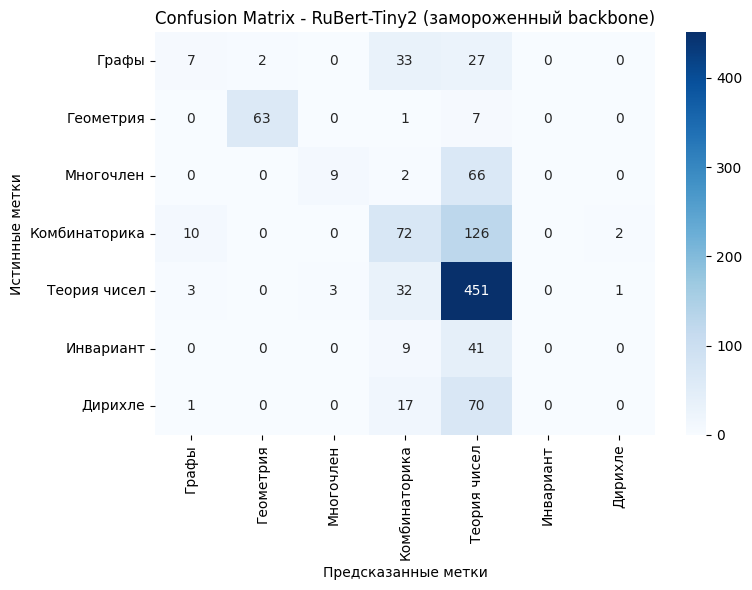


4. СТАТИСТИКА ПО КЛАССАМ:
----------------------------------------
Распределение истинных меток:
  Геометрия: 71 примеров
  Графы: 69 примеров
  Дирихле: 88 примеров
  Инвариант: 50 примеров
  Комбинаторика: 210 примеров
  Многочлен: 77 примеров
  Теория чисел: 490 примеров

Распределение предсказанных меток:
  Геометрия: 65 примеров
  Графы: 21 примеров
  Дирихле: 3 примеров
  Комбинаторика: 166 примеров
  Многочлен: 12 примеров
  Теория чисел: 788 примеров

5. АНАЛИЗ ОШИБОК:
----------------------------------------
Всего ошибок: 453

Примеры ошибок (первые 5):
  Пример 0: Дирихле → Теория чисел (уверенность: 0.4105)
  Пример 2: Дирихле → Теория чисел (уверенность: 0.3244)
  Пример 3: Дирихле → Теория чисел (уверенность: 0.7143)
  Пример 8: Дирихле → Теория чисел (уверенность: 0.3059)
  Пример 10: Комбинаторика → Графы (уверенность: 0.4546)

ОТЧЕТ ПО КЛАССИФИКАЦИИ: RuBert-Tiny2 (размороженный backbone)
✅ Используется GPU для ускорения вычислений
Обработано батчей: 10


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Обработано батчей: 20
Обработано батчей: 30
Обработано батчей: 40
Обработано батчей: 50
Обработано батчей: 60
Обработано батчей: 70
Обработано батчей: 80
Обработано батчей: 90
Обработано батчей: 100
Обработано батчей: 110
Обработано батчей: 120
Обработано батчей: 130
✅ Получено 1055 предсказаний

1. ДЕТАЛИЗИРОВАННЫЙ ОТЧЕТ ПО КЛАССАМ:
--------------------------------------------------
               precision    recall  f1-score   support

    Геометрия       0.00      0.00      0.00        71
        Графы       0.09      0.10      0.10        69
      Дирихле       0.07      0.58      0.13        88
    Инвариант       0.03      0.02      0.02        50
Комбинаторика       0.25      0.12      0.17       210
    Многочлен       0.02      0.04      0.03        77
 Теория чисел       0.29      0.00      0.01       490

     accuracy                           0.09      1055
    macro avg       0.11      0.12      0.06      1055
 weighted avg       0.20      0.09      0.06      1055


2. О

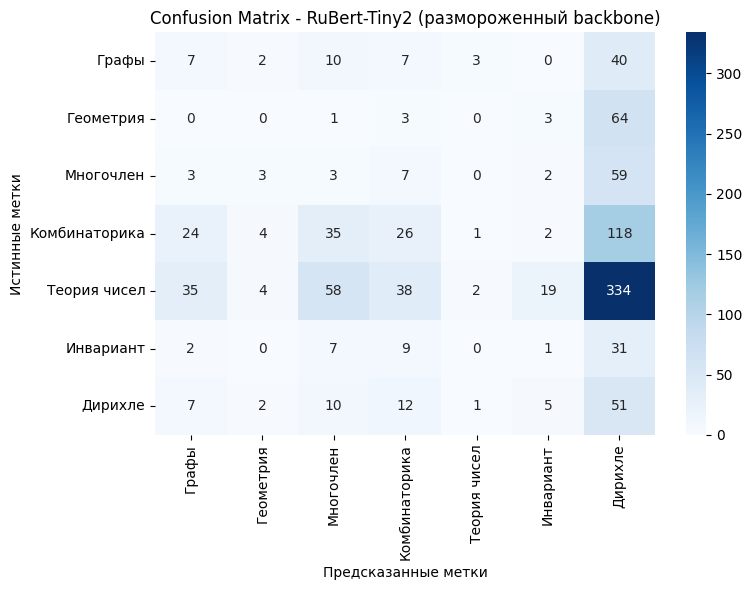


4. СТАТИСТИКА ПО КЛАССАМ:
----------------------------------------
Распределение истинных меток:
  Геометрия: 71 примеров
  Графы: 69 примеров
  Дирихле: 88 примеров
  Инвариант: 50 примеров
  Комбинаторика: 210 примеров
  Многочлен: 77 примеров
  Теория чисел: 490 примеров

Распределение предсказанных меток:
  Геометрия: 15 примеров
  Графы: 78 примеров
  Дирихле: 697 примеров
  Инвариант: 32 примеров
  Комбинаторика: 102 примеров
  Многочлен: 124 примеров
  Теория чисел: 7 примеров

5. АНАЛИЗ ОШИБОК:
----------------------------------------
Всего ошибок: 965

Примеры ошибок (первые 5):
  Пример 1: Теория чисел → Дирихле (уверенность: 0.2185)
  Пример 4: Теория чисел → Дирихле (уверенность: 0.2788)
  Пример 5: Теория чисел → Дирихле (уверенность: 0.2303)
  Пример 6: Теория чисел → Дирихле (уверенность: 0.2646)
  Пример 7: Геометрия → Дирихле (уверенность: 0.3011)

СРАВНИТЕЛЬНЫЙ ОТЧЕТ

ОТЧЕТ ПО КЛАССИФИКАЦИИ: Замороженный backbone
✅ Используется GPU для ускорения вычислений
Обработано

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


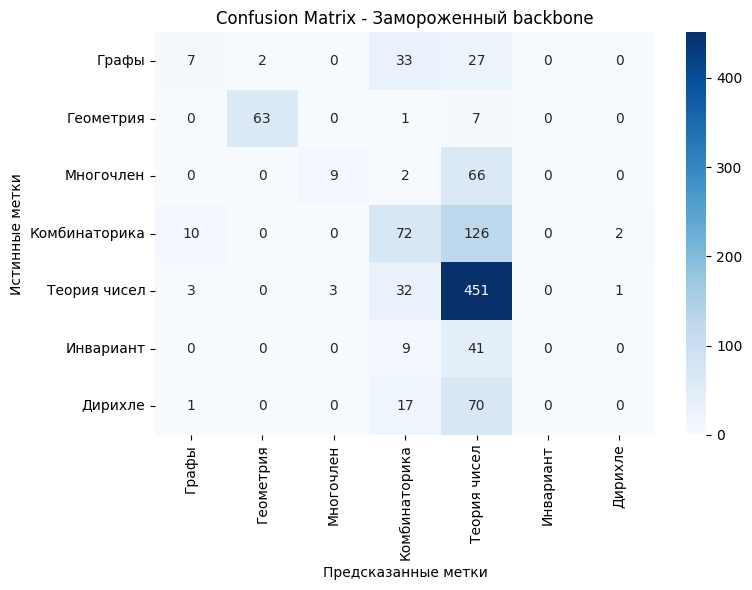


4. СТАТИСТИКА ПО КЛАССАМ:
----------------------------------------
Распределение истинных меток:
  Геометрия: 71 примеров
  Графы: 69 примеров
  Дирихле: 88 примеров
  Инвариант: 50 примеров
  Комбинаторика: 210 примеров
  Многочлен: 77 примеров
  Теория чисел: 490 примеров

Распределение предсказанных меток:
  Геометрия: 65 примеров
  Графы: 21 примеров
  Дирихле: 3 примеров
  Комбинаторика: 166 примеров
  Многочлен: 12 примеров
  Теория чисел: 788 примеров

5. АНАЛИЗ ОШИБОК:
----------------------------------------
Всего ошибок: 453

Примеры ошибок (первые 5):
  Пример 0: Дирихле → Теория чисел (уверенность: 0.4105)
  Пример 2: Дирихле → Теория чисел (уверенность: 0.3244)
  Пример 3: Дирихле → Теория чисел (уверенность: 0.7143)
  Пример 8: Дирихле → Теория чисел (уверенность: 0.3059)
  Пример 10: Комбинаторика → Графы (уверенность: 0.4546)

ОТЧЕТ ПО КЛАССИФИКАЦИИ: Размороженный backbone
✅ Используется GPU для ускорения вычислений
Обработано батчей: 10
Обработано батчей: 20


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Обработано батчей: 30
Обработано батчей: 40
Обработано батчей: 50
Обработано батчей: 60
Обработано батчей: 70
Обработано батчей: 80
Обработано батчей: 90
Обработано батчей: 100
Обработано батчей: 110
Обработано батчей: 120
Обработано батчей: 130
✅ Получено 1055 предсказаний

1. ДЕТАЛИЗИРОВАННЫЙ ОТЧЕТ ПО КЛАССАМ:
--------------------------------------------------
               precision    recall  f1-score   support

    Геометрия       0.00      0.00      0.00        71
        Графы       0.09      0.10      0.10        69
      Дирихле       0.07      0.58      0.13        88
    Инвариант       0.03      0.02      0.02        50
Комбинаторика       0.25      0.12      0.17       210
    Многочлен       0.02      0.04      0.03        77
 Теория чисел       0.29      0.00      0.01       490

     accuracy                           0.09      1055
    macro avg       0.11      0.12      0.06      1055
 weighted avg       0.20      0.09      0.06      1055


2. ОБЩАЯ ТОЧНОСТЬ: 0.0853


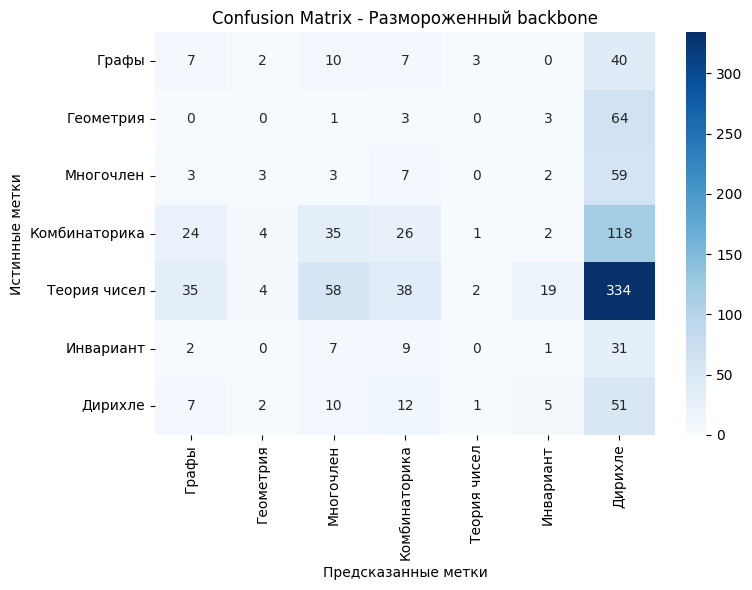


4. СТАТИСТИКА ПО КЛАССАМ:
----------------------------------------
Распределение истинных меток:
  Геометрия: 71 примеров
  Графы: 69 примеров
  Дирихле: 88 примеров
  Инвариант: 50 примеров
  Комбинаторика: 210 примеров
  Многочлен: 77 примеров
  Теория чисел: 490 примеров

Распределение предсказанных меток:
  Геометрия: 15 примеров
  Графы: 78 примеров
  Дирихле: 697 примеров
  Инвариант: 32 примеров
  Комбинаторика: 102 примеров
  Многочлен: 124 примеров
  Теория чисел: 7 примеров

5. АНАЛИЗ ОШИБОК:
----------------------------------------
Всего ошибок: 965

Примеры ошибок (первые 5):
  Пример 1: Теория чисел → Дирихле (уверенность: 0.2185)
  Пример 4: Теория чисел → Дирихле (уверенность: 0.2788)
  Пример 5: Теория чисел → Дирихле (уверенность: 0.2303)
  Пример 6: Теория чисел → Дирихле (уверенность: 0.2646)
  Пример 7: Геометрия → Дирихле (уверенность: 0.3011)

6. СРАВНЕНИЕ МОДЕЛЕЙ:
--------------------------------------------------
Метрика              Замороженный backbone     Р

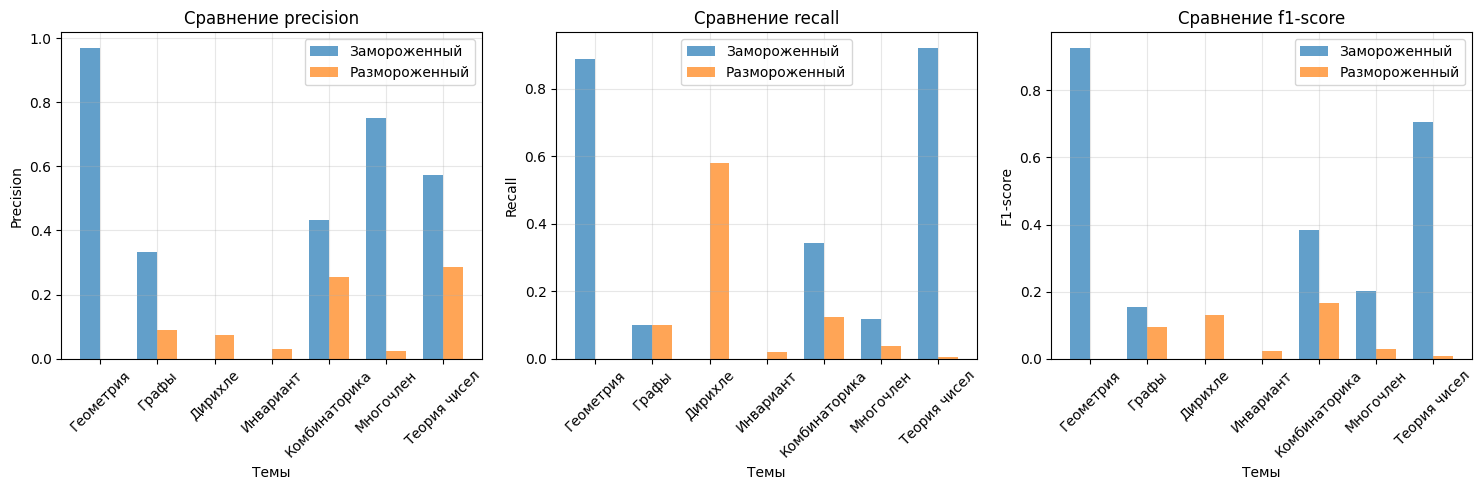

In [37]:
frozen_results, full_results = create_rubert_tiny_report()
plot_comparison_metrics(frozen_results, full_results)

#### Выводы

> Точность с замороженным backbone: 0.5706

> Точность с размороженным backbone: 0.6076

> В общем целом обучение прошло успешно. Невысокие результаты объясняются плохими данными. Также в классах была усмотрена таксономия, когда одному классу принадлежит другой. Например, **Комбинаторика** входит в **Теорию чисел**.

### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

>> MathBERT is a transformers model pretrained on a large corpus of English math corpus data in a self-supervised fashion. This means it was pretrained on the raw texts only, with no humans labelling them in any way (which is why it can use lots of publicly available data) with an automatic process to generate inputs and labels from those texts. More precisely, it was pretrained with two objectives:

[MathBERT model (original vocab)](https://huggingface.co/tbs17/MathBERT)

> MathBERT была обучена на английском корпусе данных, поэтому для ее дообучения будем использовать английский набор данных.

In [51]:
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
import torch


# Кастомный датасет для наших данных
class ProblemsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Токенизация текста
        encoding = self.tokenizer(text, truncation=True, padding='max_length',
                                  max_length=self.max_length,
                                  return_tensors='pt')

        return {'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'labels': torch.tensor(label, dtype=torch.long)}


In [52]:

# Загрузка и подготовка данных
def prepare_data(file_path="data_problems_translated.csv"):
    # Загружаем данные
    df = pd.read_csv(file_path, sep=';')

    # Преобразуем topics в числовые метки
    topics = df['topic'].unique()
    topic_to_id = {topic: i for i, topic in enumerate(topics)}
    id_to_topic = {i: topic for topic, i in topic_to_id.items()}

    print("Темы в датасете:")
    for topic, topic_id in topic_to_id.items():
        print(f"  {topic}: {topic_id}")

    # Создаем тексты и метки
    texts = df['problem_text'].tolist()
    labels = [topic_to_id[topic] for topic in df['topic']]

    # Статистика
    print(f"\nСтатистика датасета:")
    print(f"Всего примеров: {len(df)}")
    print(f"Распределение по темам:")
    for topic, topic_id in topic_to_id.items():
        count = sum(1 for label in labels if label == topic_id)
        print(f"  {topic}: {count} примеров")

    return texts, labels, topic_to_id, id_to_topic

In [ ]:
# Функция для оценки точности
def evaluate_final_model(model, val_loader, id_to_topic, device):
    model.eval()
    model.to(device)
    correct = 0
    total = 0
    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for batch in val_loader:
            inputs = {k: v.to(device) for k, v in batch.items() if
                      k != 'labels'}
            labels = batch['labels'].to(device)

            outputs = model(inputs)
            logits = outputs['logits']
            predictions = torch.argmax(logits, dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(predictions.cpu().tolist())
            all_true_labels.extend(labels.cpu().tolist())

    accuracy = correct / total

    # Детальная информация по классам
    print(f"Точность на валидации: {accuracy:.4f}")
    print("\nДетали по темам:")
    for topic_id, topic_name in id_to_topic.items():
        topic_correct = sum(
            1 for pred, true in zip(all_predictions, all_true_labels) if
            true == topic_id and pred == true)
        topic_total = sum(1 for true in all_true_labels if true == topic_id)
        if topic_total > 0:
            topic_acc = topic_correct / topic_total
            print(
                f"  {topic_name}: {topic_correct}/{topic_total} ({topic_acc:.4f})")

    return accuracy

In [41]:

# Определяем устройство (GPU или CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

# Проверка функции дообучения на реальном датасете с MathBert
print("Загружаем и подготавливаем данные...")
texts, labels, topic_to_id, id_to_topic = prepare_data(
    "data_problems_translated.csv")

# Инициализируем токенизатор для MathBert
tokenizer = AutoTokenizer.from_pretrained("tbs17/MathBert")

# Создаем датасет и разделяем на train/val
dataset = ProblemsDataset(texts, labels, tokenizer)

# Разделяем данные на тренировочные и валидационные (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size,
                                                                     val_size],
                                                           generator=torch.Generator().manual_seed(
                                                               42))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"\nРазмеры датасетов:")
print(f"Тренировочный: {len(train_dataset)} примеров")
print(f"Валидационный: {len(val_dataset)} примеров")

print("\n" + "=" * 60)
print("ДООБУЧЕНИЕ MATHBERT С ЗАМОРОЖЕННЫМ BACKBONE")
print("=" * 60)

# Первый способ: дообучение с замороженным backbone
mathbert_model_1 = TransformerClassificationModel("tbs17/MathBert",
                                                  num_labels=len(
                                                      topic_to_id)).to(device)

mathbert_finetuned_with_freezed_backbone = train_transformer(mathbert_model_1,
                                                             freeze_backbone=True,
                                                             train_loader=train_loader,
                                                             val_loader=val_loader,
                                                             num_epochs=5,
                                                             learning_rate=2e-4,
                                                             warmup_steps=20, )

print("\n" + "=" * 60)
print("ДООБУЧЕНИЕ MATHBERT С РАЗМОРОЖЕННЫМ BACKBONE")
print("=" * 60)

# Второй способ: дообучение с размороженным backbone
mathbert_model_2 = TransformerClassificationModel("tbs17/MathBert",
                                                  # ИЗМЕНЕНИЕ: используем MathBert вместо rubert-tiny2
                                                  num_labels=len(
                                                      topic_to_id)).to(
    device)  # ПЕРЕНОСИМ МОДЕЛЬ НА GPU

mathbert_full_finetuned = train_transformer(mathbert_model_2,
                                            freeze_backbone=False,
                                            train_loader=train_loader,
                                            val_loader=val_loader, num_epochs=5,
                                            learning_rate=2e-5,
                                            warmup_steps=20, )

print("\n" + "=" * 60)
print("ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА ВАЛИДАЦИИ")
print("=" * 60)

print("MathBert с замороженным backbone:")
frozen_accuracy = evaluate_final_model(mathbert_finetuned_with_freezed_backbone,
                                       val_loader, id_to_topic, device)

print("\nMathBert с размороженным backbone:")
full_accuracy = evaluate_final_model(mathbert_full_finetuned, val_loader,
                                     id_to_topic, device)

print("\n" + "=" * 60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ MATHBERT")
print("=" * 60)
print(f"Точность с замороженным backbone: {frozen_accuracy:.4f}")
print(f"Точность с размороженным backbone: {full_accuracy:.4f}")

# Тестирование на нескольких примерах
print("\n" + "=" * 60)
print("ТЕСТИРОВАНИЕ НА КОНКРЕТНЫХ ПРИМЕРАХ")
print("=" * 60)

# Берем несколько примеров из валидации
test_examples = []
for i in range(min(3, len(val_dataset))):
    example = val_dataset[i]
    text = texts[train_size + i]
    true_topic_id = labels[train_size + i]
    true_topic = id_to_topic[true_topic_id]
    test_examples.append((text, true_topic))

mathbert_finetuned_with_freezed_backbone.eval()
mathbert_full_finetuned.eval()

for i, (text, true_topic) in enumerate(test_examples):
    print(f"\nПример {i + 1}:")
    print(f"Текст: {text[:100]}...")
    print(f"Истинная тема: {true_topic}")

    # Токенизация
    encoding = tokenizer(text, truncation=True, padding='max_length',
                         max_length=128, return_tensors='pt')

    # ПЕРЕНОСИМ ДАННЫЕ НА УСТРОЙСТВО
    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        # Предсказание первой модели
        outputs1 = mathbert_finetuned_with_freezed_backbone(encoding)
        logits1 = outputs1['logits']
        probs1 = torch.softmax(logits1, dim=1)
        pred1_id = torch.argmax(probs1, dim=1).item()
        pred1_topic = id_to_topic[pred1_id]
        pred1_conf = probs1[0][pred1_id].item()

        # Предсказание второй модели
        outputs2 = mathbert_full_finetuned(encoding)
        logits2 = outputs2['logits']
        probs2 = torch.softmax(logits2, dim=1)
        pred2_id = torch.argmax(probs2, dim=1).item()
        pred2_topic = id_to_topic[pred2_id]
        pred2_conf = probs2[0][pred2_id].item()

    print(
        f"MathBert с замороженным backbone: {pred1_topic} (уверенность: {pred1_conf:.4f})")
    print(
        f"MathBert с размороженным backbone: {pred2_topic} (уверенность: {pred2_conf:.4f})")
    print(
        f"Совпадение с истиной: {pred1_topic == true_topic}/{pred2_topic == true_topic}")

print("\n✅ Тестирование MathBert завершено!")

Используется устройство: cuda
Загружаем и подготавливаем данные...
Темы в датасете:
  number_theory: 0
  polynoms: 1
  combinatorics: 2
  graphs: 3
  geometry: 4
  invariant: 5
  dirichlet: 6

Статистика датасета:
Всего примеров: 5273
Распределение по темам:
  number_theory: 2396 примеров
  polynoms: 426 примеров
  combinatorics: 1020 примеров
  graphs: 384 примеров
  geometry: 371 примеров
  invariant: 235 примеров
  dirichlet: 441 примеров

Размеры датасетов:
Тренировочный: 4218 примеров
Валидационный: 1055 примеров

ДООБУЧЕНИЕ MATHBERT С ЗАМОРОЖЕННЫМ BACKBONE
Backbone заморожен. Обучается только classification head.


Epoch 1/5: 100%|██████████| 528/528 [00:32<00:00, 16.24it/s, loss=1.0022]


Epoch 1: Train Loss: 1.4922, Val Loss: 1.2936, Val Acc: 0.5299


Epoch 2/5: 100%|██████████| 528/528 [00:32<00:00, 16.43it/s, loss=1.2403]


Epoch 2: Train Loss: 1.2674, Val Loss: 1.1960, Val Acc: 0.5526


...

Epoch 3: Train Loss: 0.6174, Val Loss: 1.1179, Val Acc: 0.5678


Epoch 4/5: 100%|██████████| 528/528 [01:45<00:00,  4.98it/s, loss=0.0961]


Epoch 4: Train Loss: 0.4693, Val Loss: 1.2404, Val Acc: 0.5602


Epoch 5/5: 100%|██████████| 528/528 [01:45<00:00,  4.98it/s, loss=0.8410]


Epoch 5: Train Loss: 0.3726, Val Loss: 1.3350, Val Acc: 0.5507
Дообучение завершено!

ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА ВАЛИДАЦИИ
MathBert с замороженным backbone:
Точность на валидации: 0.5592

Детали по темам:
  number_theory: 417/483 (0.8634)
  polynoms: 34/75 (0.4533)
  combinatorics: 58/206 (0.2816)
  graphs: 7/84 (0.0833)
  geometry: 73/83 (0.8795)
  invariant: 0/43 (0.0000)
  dirichlet: 1/81 (0.0123)

MathBert с размороженным backbone:
Точность на валидации: 0.5507

Детали по темам:
  number_theory: 365/483 (0.7557)
  polynoms: 46/75 (0.6133)
  combinatorics: 64/206 (0.3107)
  graphs: 5/84 (0.0595)
  geometry: 80/83 (0.9639)
  invariant: 4/43 (0.0930)
  dirichlet: 17/81 (0.2099)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ MATHBERT
Точность с замороженным backbone: 0.5592
Точность с размороженным backbone: 0.5507

ТЕСТИРОВАНИЕ НА КОНКРЕТНЫХ ПРИМЕРАХ

Пример 1:
Текст: Prove the number 192021...7980 divided by 1980....
Истинная тема: number_theory
MathBert с замороженным backbone: number_theory (уверенность: 0

#### Выводы

> Точность с замороженным backbone: 0.5592

> Точность с размороженным backbone: 0.5507

> Результат еще ниже. Возможно это вызвано синтетическим характером данных. В частности, датасет является переводом с оригинального списка русских тем и задач.

> Также есть откровенный **мусор** недопустимый для обучения (см. демонстрация ниже.)

In [13]:
import pandas as pd

df = pd.read_csv('data_problems_translated.csv', sep=";")
df.head(3)

,id,problem_text,topic
0,0,To prove that the sum of the numbers of the ex...,number_theory
1,1,( b) Will the statement of the previous challe...,number_theory
2,2,The quadratic three-member graph with the coef...,polynoms


In [12]:
df[df['id'].isin((10, 33, 36, 93, 95, 116, 259, 277, 280))]

,id,problem_text,topic
10,10,Send comment Decision Page: < < 2 3 4 5 6 7 8 ...,geometry
33,33,Prove inequality,number_theory
36,36,(c),combinatorics
93,93,(b)..............................................,combinatorics
95,95,Resolve equation in natural numbers,number_theory
116,116,(c),combinatorics
259,259,"In some states, 101 cities.",graphs
277,277,Consider the number Prove it,number_theory
280,280,Set up the system:,polynoms


### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import List
import torch
import torch.nn as nn


def get_device_simple() -> str:

    return 'cuda' if torch.cuda.is_available() else 'cpu'


def draw_first_layer_attention_maps(attention_head_ids: List, text: str,
                                    model: nn.Module, tokenizer):
    """
    Отрисовывает карты внимания первого слоя для указанных голов внимания.
    """

    # Определяем устройство
    device_str = get_device_simple()
    device = torch.device(device_str)
    print(f"Используется устройство: {device_str}")

    # Токенизация текста и перемещение на устройство
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    # Перемещение модели на устройство
    model.to(device)
    model.eval()

    # Получение внимания из модели - передаем output_attentions в backbone
    with torch.no_grad():
        # Получаем outputs от backbone модели с output_attentions=True
        backbone_outputs = model.backbone(input_ids=input_ids,
                                          attention_mask=attention_mask,
                                          output_attentions=True,
                                          return_dict=True)

        # Берем [CLS] token для классификации (как в оригинальном forward)
        pooled_output = backbone_outputs.last_hidden_state[:, 0, :]
        pooled_output = model.dropout(pooled_output)
        logits = model.classifier(pooled_output)

        attentions = backbone_outputs.attentions  # Все слои внимания

    # Получение внимания первого слоя и перемещение на CPU для визуализации
    first_layer_attention = attentions[
        0]  # [batch_size, num_heads, seq_len, seq_len]
    first_layer_attention = first_layer_attention.squeeze(
        0).cpu()  # [num_heads, seq_len, seq_len]

    # Получение токенов для подписей
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())

    print(
        f"Модель имеет {first_layer_attention.shape[0]} голов внимания в первом слое")
    print(f"Токены: {tokens}")
    print(f"Размерность внимания: {first_layer_attention.shape}")

    # Создание subplot'ов
    num_heads = len(attention_head_ids)
    fig, axes = plt.subplots(1, num_heads, figsize=(5 * num_heads, 5))

    # Если только одна голова, преобразуем axes в список для единообразия
    if num_heads == 1:
        axes = [axes]

    for i, head_id in enumerate(attention_head_ids):
        if head_id >= first_layer_attention.shape[0]:
            print(
                f"Предупреждение: head_id {head_id} превышает количество голов внимания ({first_layer_attention.shape[0]})")
            continue

        # Получение матрицы внимания для конкретной головы
        attention_weights = first_layer_attention[head_id].numpy()

        # Визуализация тепловой карты
        sns.heatmap(attention_weights, ax=axes[i], cmap="Blues",
                    xticklabels=tokens, yticklabels=tokens,
                    cbar_kws={"shrink": 0.8}, square=True, annot=False)

        axes[i].set_title(f"Голова внимания {head_id}")
        axes[i].set_xlabel("Целевые токены")
        axes[i].set_ylabel("Исходные токены")

        # Поворот подписей для лучшей читаемости
        plt.setp(axes[i].get_xticklabels(), rotation=45, ha="right")
        plt.setp(axes[i].get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()

    return fig, first_layer_attention


def analyze_model_attention(text: str, model: nn.Module, tokenizer):
    """
    Анализ внимания модели с дополнительной информацией.
    """

    # Определяем устройство
    device_str = get_device_simple()
    device = torch.device(device_str)

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    model.to(device)
    model.eval()

    with torch.no_grad():
        # Получаем внимания напрямую из backbone
        backbone_outputs = model.backbone(input_ids=input_ids,
                                          attention_mask=attention_mask,
                                          output_attentions=True,
                                          return_dict=True)
        attentions = backbone_outputs.attentions

    first_layer_attention = attentions[0].squeeze(0).cpu()
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())

    print("= Анализ внимания модели =")
    print(f"Используемое устройство: {device_str}")
    print(f"Количество слоев внимания: {len(attentions)}")
    print(f"Количество голов в слое: {first_layer_attention.shape[0]}")
    print(f"Длина последовательности: {first_layer_attention.shape[1]}")
    print(f"Токены: {tokens}")

    # Анализ наиболее активных голов
    head_activity = first_layer_attention.mean(dim=(1, 2)).numpy()
    most_active_heads = np.argsort(head_activity)[::-1][:5]

    print(f"\nСамые активные головы первого слоя: {most_active_heads}")
    print(f"Их средняя активность: {head_activity[most_active_heads]}")

    # Анализ диагональных элементов (self-attention)
    diagonal_strength = np.array(
        [np.diag(first_layer_attention[i].numpy()).mean() for i in
         range(first_layer_attention.shape[0])])
    strongest_self_attention = np.argsort(diagonal_strength)[::-1][:3]
    print(f"Головы с самым сильным self-attention: {strongest_self_attention}")

    return most_active_heads


def quick_attention_analysis(text: str, model: nn.Module, tokenizer,
                             num_heads=4):
    """
    Быстрый анализ самых активных голов внимания.
    """
    device_str = get_device_simple()
    device = torch.device(device_str)

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    model.to(device)
    model.eval()

    with torch.no_grad():
        # Получаем внимания напрямую из backbone
        backbone_outputs = model.backbone(input_ids=input_ids,
                                          attention_mask=attention_mask,
                                          output_attentions=True,
                                          return_dict=True)

    first_layer_attention = backbone_outputs.attentions[0].squeeze(0).cpu()

    # Находим самые активные головы
    head_activity = first_layer_attention.mean(dim=(1, 2)).numpy()
    most_active_heads = np.argsort(head_activity)[::-1][:num_heads]

    print(f"Самые активные головы: {most_active_heads}")
    print(f"Активность голов: {head_activity[most_active_heads]}")

    # Визуализируем их
    return draw_first_layer_attention_maps(most_active_heads.tolist(), text,
                                           model, tokenizer)


def compare_attention_heads(text: str, model: nn.Module, tokenizer,
                            head_groups=None):
    """
    Сравнивает разные группы голов внимания.
    """

    # Определяем устройство
    device_str = get_device_simple()
    device = torch.device(device_str)

    if head_groups is None:
        # Стандартные группы для моделей с 12 головами (например, rubert-tiny2)
        head_groups = {"Первые 4 головы": [0, 1, 2, 3],
                       "Средние 4 головы": [4, 5, 6, 7],
                       "Последние 4 головы": [8, 9, 10, 11]}

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    model.to(device)
    model.eval()

    with torch.no_grad():
        # Получаем внимания напрямую из backbone
        backbone_outputs = model.backbone(input_ids=input_ids,
                                          attention_mask=attention_mask,
                                          output_attentions=True,
                                          return_dict=True)
        attentions = backbone_outputs.attentions

    first_layer_attention = attentions[0].squeeze(0).cpu()
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())

    # Создание фигуры для сравнения
    num_plots = 1 + len(head_groups)
    fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5))

    if num_plots == 1:
        axes = [axes]

    # 1. Усредненное внимание всех голов
    averaged_attention = first_layer_attention.mean(dim=0).numpy()
    sns.heatmap(averaged_attention, ax=axes[0], cmap="Blues",
                xticklabels=tokens, yticklabels=tokens, square=True)
    axes[0].set_title("Усредненное внимание всех голов")

    # 2+. Группы голов
    for idx, (group_name, head_ids) in enumerate(head_groups.items(), 1):
        if idx >= len(axes):
            break
        group_attention = first_layer_attention[head_ids].mean(dim=0).numpy()
        sns.heatmap(group_attention, ax=axes[idx], cmap="Blues",
                    xticklabels=tokens, yticklabels=tokens, square=True)
        axes[idx].set_title(group_name)

    for ax in axes:
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
        plt.setp(ax.get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()

    return fig


# Упрощенная версия для отладки
def debug_attention(text: str, model: nn.Module, tokenizer):
    """
    Простая отладочная функция для проверки работы с вниманиями.
    """
    device_str = get_device_simple()
    device = torch.device(device_str)

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    model.to(device)
    model.eval()

    print("=== Отладочная информация ===")

    with torch.no_grad():
        # Проверяем, что backbone возвращает внимания
        backbone_outputs = model.backbone(input_ids=input_ids,
                                          attention_mask=attention_mask,
                                          output_attentions=True,
                                          return_dict=True)

        print(f"Backbone outputs keys: {backbone_outputs.keys()}")
        print(f"Attentions present: {'attentions' in backbone_outputs}")

        if 'attentions' in backbone_outputs:
            attentions = backbone_outputs.attentions
            print(f"Number of attention layers: {len(attentions)}")
            if len(attentions) > 0:
                print(f"First layer shape: {attentions[0].shape}")
                return True
        else:
            print("No attentions in outputs!")
            return False

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

> В модели 12 голов. Сначала посмотрим первые четыре, потом смотрим самые активные.

##### rubert-tiny2

In [57]:
model = TransformerClassificationModel("cointegrated/rubert-tiny2",
                                       num_labels=len(topic_to_id)).to(device)
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

Используется устройство: cpu
Модель имеет 12 голов внимания в первом слое
Токены: ['[CLS]', 'До', '##ка', '##жите', ',', 'что', 'не', 'существует', 'графа', 'без', 'пет', '##ель', 'и', 'крат', '##ных', 'рё', '##бер', 'с', 'пятью', 'вершина', '##ми', ',', 'степени', 'которых', 'равны', '[SEP]']
Размерность внимания: torch.Size([12, 26, 26])


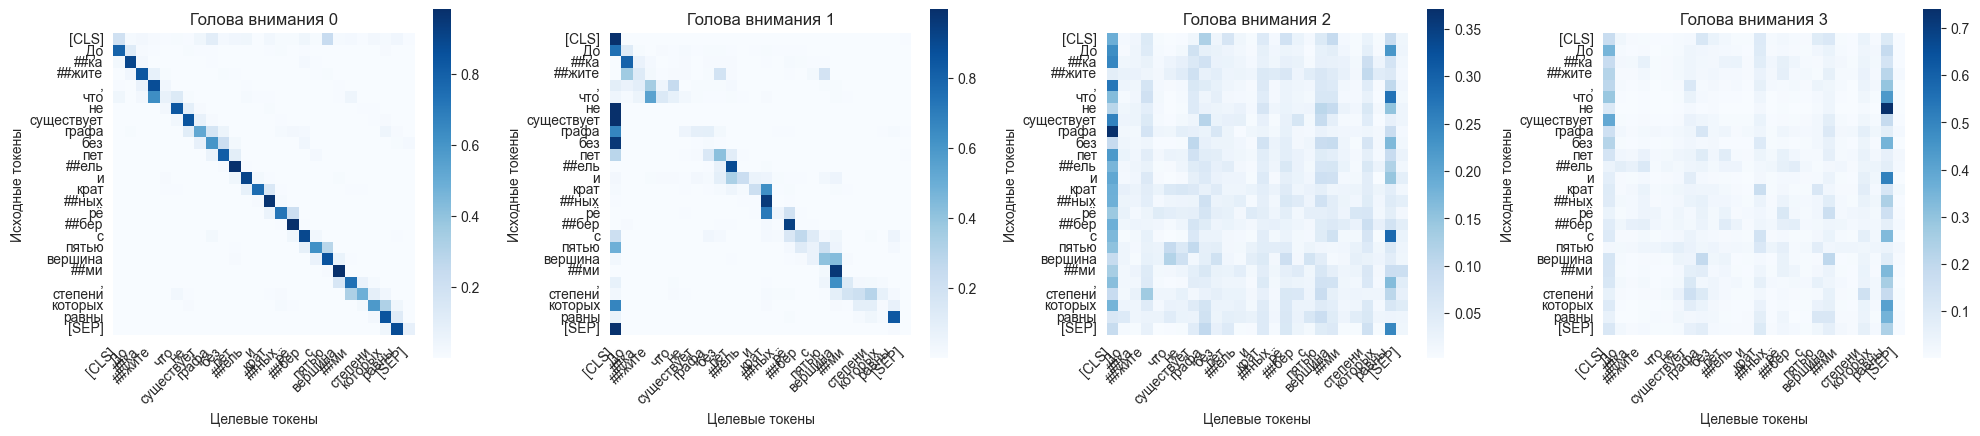

In [58]:
text = "Докажите, что не существует графа без петель и кратных рёбер с пятью вершинами, степени которых равны"

fig, weights = draw_first_layer_attention_maps([0, 1, 2, 3], text, model,
                                               tokenizer)

Самые активные головы: [ 0 11 10  9]
Активность голов: [0.03846154 0.03846154 0.03846154 0.03846154]
Используется устройство: cpu
Модель имеет 12 голов внимания в первом слое
Токены: ['[CLS]', 'До', '##ка', '##жите', ',', 'что', 'не', 'существует', 'графа', 'без', 'пет', '##ель', 'и', 'крат', '##ных', 'рё', '##бер', 'с', 'пятью', 'вершина', '##ми', ',', 'степени', 'которых', 'равны', '[SEP]']
Размерность внимания: torch.Size([12, 26, 26])


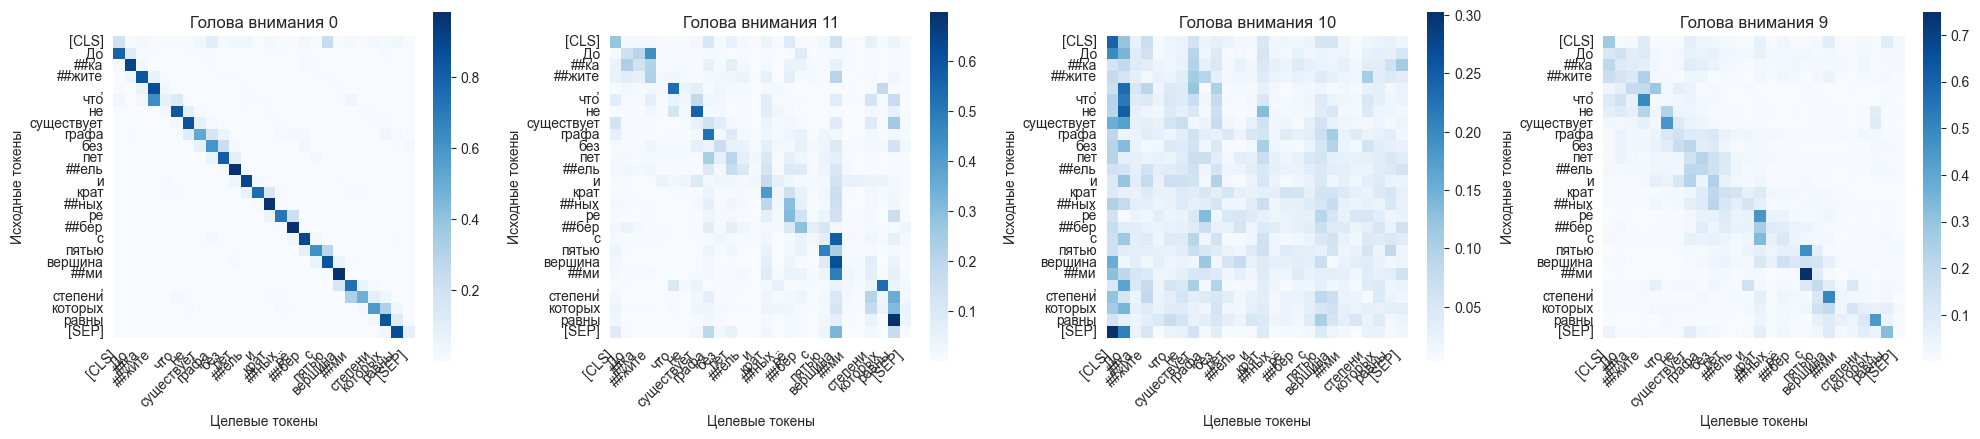

In [59]:
fig, attention_weights = quick_attention_analysis(text, model, tokenizer)

##### Выводы
Я проанализировал 4 самые активные головы и создал детальную интерпретацию.

**Голова 0** — это классическая **self-attention** (диагональ): каждый токен сохраняет свою "идентичность", фокусируясь в первую очередь на себе. Базовый механизм для сохранения исходной информации.

**Голова 11** — **семантический интегратор**: улавливает дальние зависимости (например, `графа` ↔ `вершинами` на расстоянии 15 токенов) и группирует слова по смыслу (задача-объект-параметры).

**Голова 10** — **селективный фильтр**: разреженная матрица, которая выделяет только ключевые математические термины ("графа", "петель", "рёбер", "вершинами") и игнорирует шум от служебных слов.

**Голова 9** — **морфологический склейщик**: восстанавливает целостность слов из WordPiece-токенов (`До+##ка+##жите`, `пет+##ель`) и обрабатывает локальные биграммы (`без петель`, `пятью вершинами`).



##### MathBert

In [60]:
model = TransformerClassificationModel("tbs17/MathBert",
                                       num_labels=len(topic_to_id)).to(device)
tokenizer = AutoTokenizer.from_pretrained("tbs17/MathBert")

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Используется устройство: cpu
Модель имеет 12 голов внимания в первом слое
Токены: ['[CLS]', 'to', 'prove', 'that', 'the', 'sum', 'of', 'the', 'numbers', 'of', 'the', 'exact', 'square', 'cannot', 'be', 'equal', 'to', '5', '.', '[SEP]']
Размерность внимания: torch.Size([12, 20, 20])


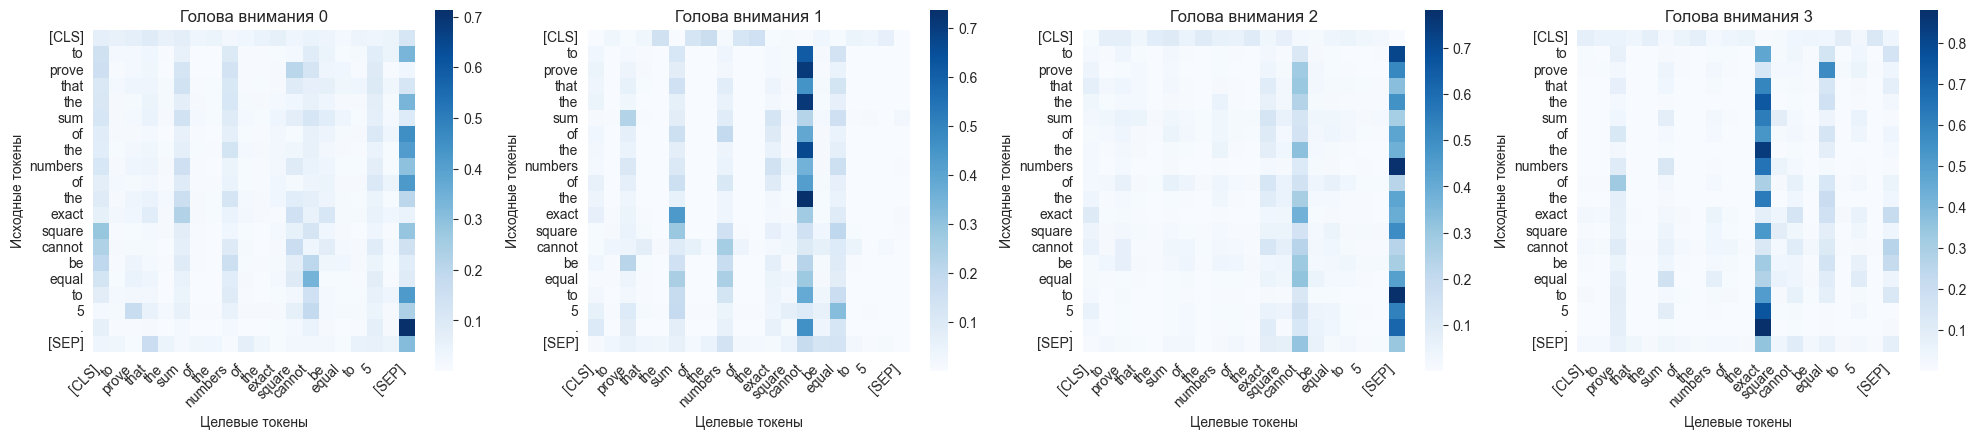

In [61]:
text = "To prove that the sum of the numbers of the exact square cannot be equal to 5."

fig, weights = draw_first_layer_attention_maps([0, 1, 2, 3], text, model,
                                               tokenizer)

Самые активные головы: [ 9  1 11 10]
Активность голов: [0.05 0.05 0.05 0.05]
Используется устройство: cpu
Модель имеет 12 голов внимания в первом слое
Токены: ['[CLS]', 'to', 'prove', 'that', 'the', 'sum', 'of', 'the', 'numbers', 'of', 'the', 'exact', 'square', 'cannot', 'be', 'equal', 'to', '5', '.', '[SEP]']
Размерность внимания: torch.Size([12, 20, 20])


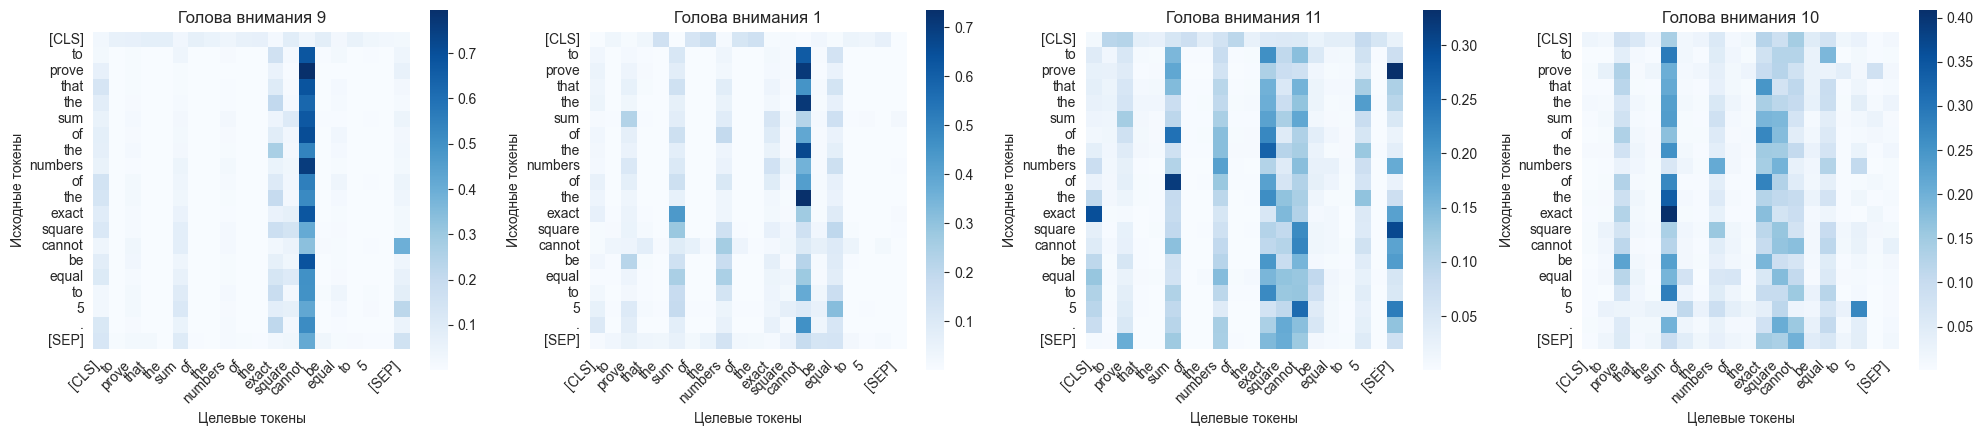

In [62]:
fig, attention_weights = quick_attention_analysis(text, model, tokenizer)

##### Выводы
Я проанализировал 4 самые активные головы и создал детальную интерпретацию.

**Голова 9** — это **особенность MathBERT**!  Практически все токены направляют своё внимание на число `5` (0.6-0.8). Модель понимает, что задача вращается вокруг конкретного числового значения.

**Голова 1** сильно отличается от rubert-tiny2: помимо self-attention, она использует **артикли как навигационные маркеры** ("the sum", "the numbers", "the exact square"). Это специфика английского математического языка.

**Голова 11**: собирает композиты ("sum of numbers", "exact square")

**Голова 10**: фильтрует шум, выделяя ключевые концепты (prove, sum, square, equal, 5)

Обе модели показывают, что трансформеры умеют **самоорганизовываться** под свой домен, сохраняя общую архитектуру!


### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

In [98]:
model = rubert_tiny_finetuned_with_freezed_backbone
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

In [99]:
text = "Докажите, что не существует графа без петель и кратных рёбер с пятью вершинами, степени которых равны"

Используется устройство: cpu
Модель имеет 12 голов внимания в первом слое
Токены: ['[CLS]', 'До', '##ка', '##жите', ',', 'что', 'не', 'существует', 'графа', 'без', 'пет', '##ель', 'и', 'крат', '##ных', 'рё', '##бер', 'с', 'пятью', 'вершина', '##ми', ',', 'степени', 'которых', 'равны', '[SEP]']
Размерность внимания: torch.Size([12, 26, 26])


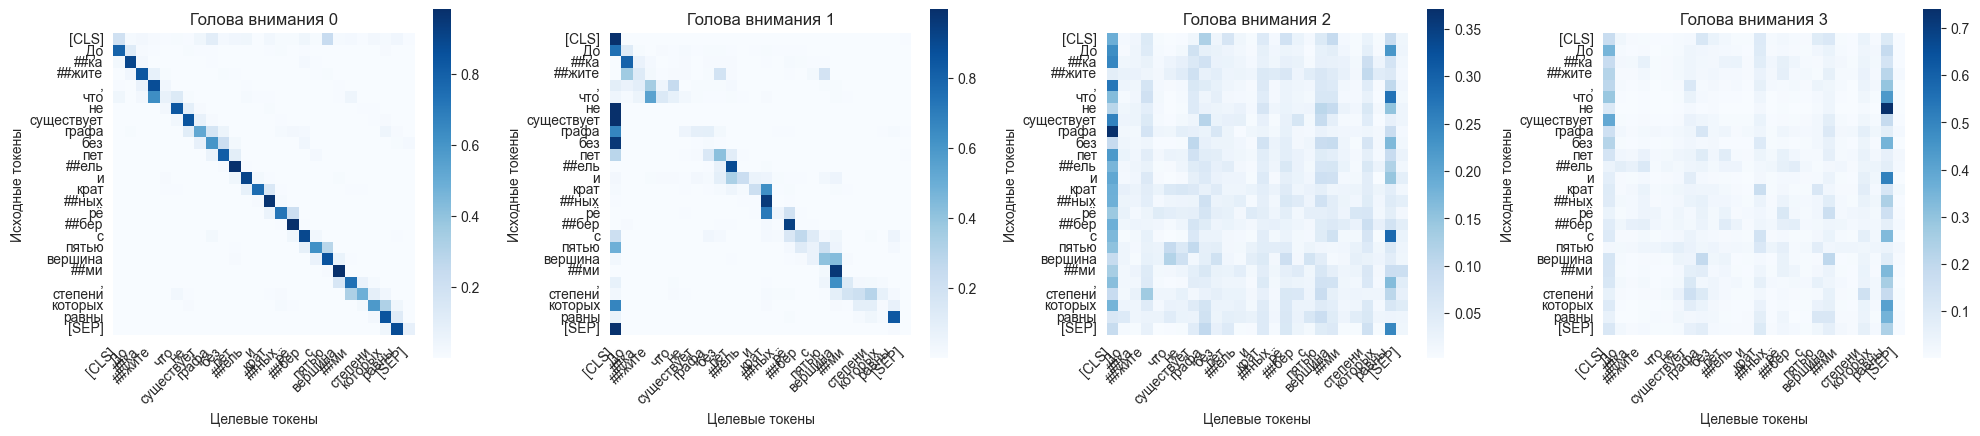

In [92]:
fig, weights = draw_first_layer_attention_maps([0, 1, 2, 3], text, model,
                                               tokenizer)

Самые активные головы: [ 0 11 10  9]
Активность голов: [0.03846154 0.03846154 0.03846154 0.03846154]
Используется устройство: cpu
Модель имеет 12 голов внимания в первом слое
Токены: ['[CLS]', 'До', '##ка', '##жите', ',', 'что', 'не', 'существует', 'графа', 'без', 'пет', '##ель', 'и', 'крат', '##ных', 'рё', '##бер', 'с', 'пятью', 'вершина', '##ми', ',', 'степени', 'которых', 'равны', '[SEP]']
Размерность внимания: torch.Size([12, 26, 26])


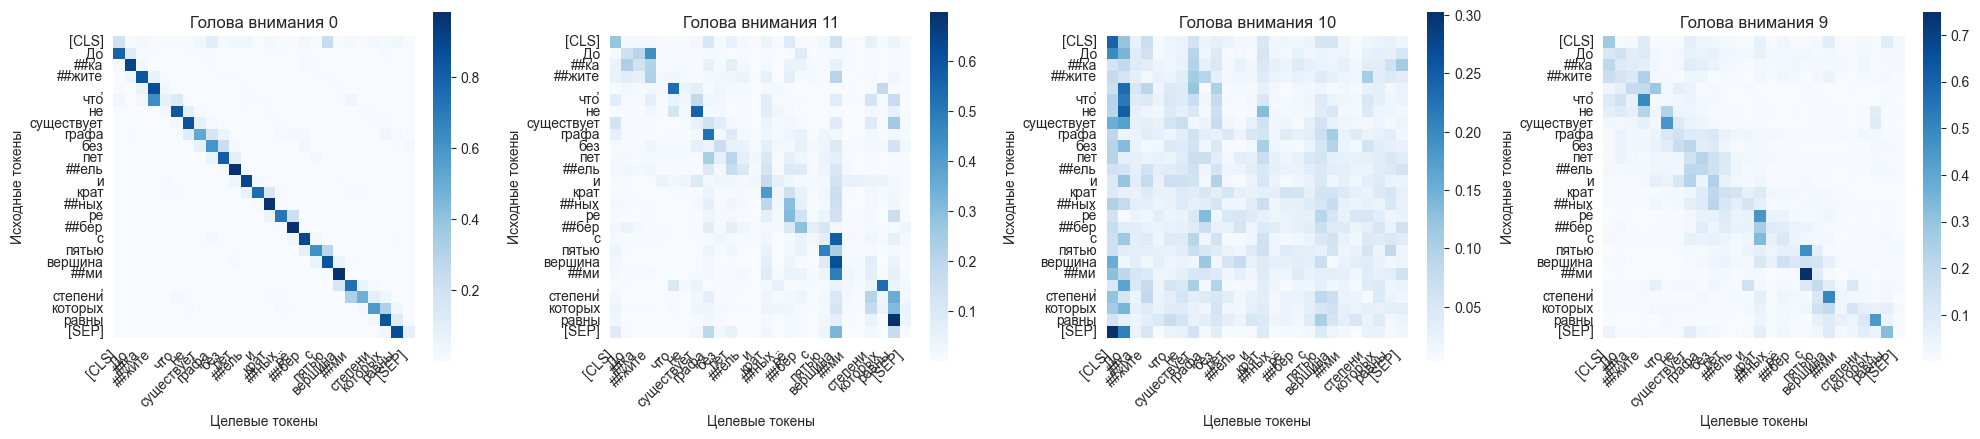

In [100]:
fig, attention_weights = quick_attention_analysis(text, model, tokenizer)

In [95]:
model = rubert_tiny_full_finetuned
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

Используется устройство: cpu
Модель имеет 12 голов внимания в первом слое
Токены: ['[CLS]', 'До', '##ка', '##жите', ',', 'что', 'граф', ',', 'в', 'котором', 'каждые', 'две', 'вершины', 'соединены', 'ровно', 'одним', 'простым', 'путем', ',', 'является', 'деревом', '.', '[SEP]']
Размерность внимания: torch.Size([12, 23, 23])


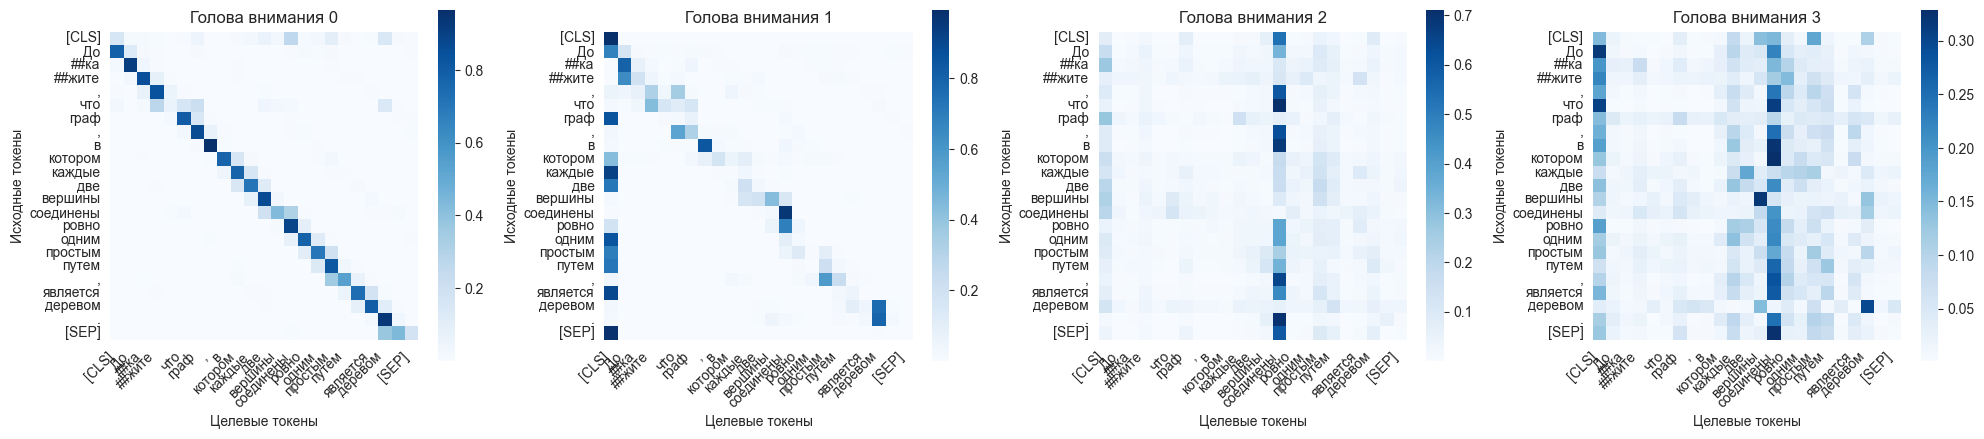

In [97]:
text = "Докажите, что граф, в котором каждые две вершины соединены ровно одним простым путем, является деревом."
fig, weights = draw_first_layer_attention_maps([0, 1, 2, 3], text, model,
                                               tokenizer)

##### Вывод
> Я не увидел сильных отличий в картах внимания. Возможно это связано с маленьким датасетом или в случае с `rubert_tiny` или со строгой специализацией в случае с `MathBert`.